In [ ]:
# cd WP10WP10_Cluster1_StatCodGen$
# pip install .
# pip install fasttext openpyxl pyreadstat utils xlrd codauto

In [73]:
import pandas as pd
import os
import sys
import re
import pickle

import requests
from io import BytesIO
import pandas as pd
from sklearn.model_selection import train_test_split

from codauto import Structured, StructuredWZ
from codauto import Codifier
from codauto import CodifierFastText



pd.set_option('display.max_colwidth', None)

#sys.path.append("/home/onyxia/work/WP10_Cluster1_StatCodGen/codauto")
#from structured import Structured, StructuredWZ
#from codifier import Codifier
#from codifier_fasttext import CodifierFastText

# German WZ Classification

In [2]:
root_path = './test'
language = 'de'

## Using Structured for German NACE

In [3]:
# Load the structure downloaded from the link provided earlier
path_struc_wz = r'./../resources'#/WP10_Cluster1_StatCodGen/de/wz_classification/' # Change the path to the location of the downloaded file
name_stuc_wz = 'WZ_2025-DE-2026-01-27-Gliederung.xlsx'
structure_wz_df = pd.read_excel(
    os.path.join(path_struc_wz, name_stuc_wz),
    sheet_name=1,
    dtype=str,
    skiprows=0,
    header=0,
    usecols=[0,2]
)
# For any classification, a DataFrame with two columns must be used: the first with the classification codes and the second with the titles.
# The codes must be provided in hierarchical order, meaning that parent classes must appear before their children.
structure_wz_df.head()

/opt/python/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Schlüssel WZ 2025,Titel
0,A,"Land- und Forstwirtschaft, Fischerei"
1,01,"Landwirtschaft, Jagd und damit verbundene Täti..."
2,01.1,Anbau ein- und zweijähriger Pflanzen
3,01.11,Anbau von anderem Getreide als Reis sowie von ...
4,01.11.0,Anbau von anderem Getreide als Reis sowie von ...


In [74]:
# Generate the instance of StructuredWZ
wz_structure = StructuredWZ(
    structure_df=structure_wz_df,
    names_l=[
    'Section',
    'Division',
    'Group',
    'Class',
    'Subclass'
    ] # Names of the levels ordered from highest to lowest hierarchy
# As a best practice, it is recommended to use underscores instead of spaces and to avoid accents
)
wz_structure.level_dict

{0: 'Section', 1: 'Division', 2: 'Group', 3: 'Class', 4: 'Subclass'}

In [ ]:
# Inspect the structure
#wz_structure.get_level('01.1')

In [ ]:
#wzs = wz_structure.load_structue(structure_wz_df)
#wzs[wzs['level'] == 1]

## Using Codifier for German NACE

In [5]:
# Get the synthetic training data

url = "https://minio.lab.sspcloud.fr/projet-aiml4os-wp10/Cluster1/synthetic_data_DE.parquet"

response = requests.get(url)
file_bytes = BytesIO(response.content)
df = pd.read_parquet(file_bytes)
df.head()

,Titel,wz_code,Generierte Daten
0,Herstellung von vorgefertigten Bauelementen un...,23.61.3,Herstellung von vorgefertigten Betonwänden.
1,Herstellung von vorgefertigten Bauelementen un...,23.61.3,Herstellung von vorgefertigten Zementfundament...
2,Herstellung von vorgefertigten Bauelementen un...,23.61.3,Herstellung von vorgefertigten Kalksandsteintr...
3,Herstellung von vorgefertigten Bauelementen un...,23.61.3,Herstellung von vorgefertigten Betonstützen.
4,Herstellung von vorgefertigten Bauelementen un...,23.61.3,Herstellung von vorgefertigten Zementdecks.


In [9]:
# df_all = pd.DataFrame({
#     'label': df['wz_code'],
#     'text': df['Generierte Daten']})

In [5]:
# # WZ test data
# train_df = pd.DataFrame({'label': ['35122', '78202', '23200', '71126']*20,
#                          'text': ['text1', 'text2', 'word1', 'word2']*20}) 
# test_df = pd.DataFrame({'label': ['35122', '78202']*20, 
#                         'text': ['tekst3', 'tekstt2']*20, 
#                         'source': ['s1', 's1']*20}) 

In [63]:
X_train, X_test, y_train, y_test = train_test_split(df['Generierte Daten'], df['wz_code'], test_size=0.05, random_state=42)

train_df = pd.DataFrame({
    'label': y_train,
    'text': X_train})

test_df = pd.DataFrame({
    'label': y_test,
    'text': X_test,
    'source': ['synthetic']*len(y_test)})

In [58]:
train_df.tail()

,label,text
119879,95.29.0,Reparatur von Türschlössern.
103694,94.99.4,Organisation von Jugendgottesdiensten.
860,23.99.0,Wir produzieren keramische Bauteile für die Elektrotechnik aus hochreinem Aluminiumoxid.
15795,33.13.0,Unser Service umfasst die Wartung von Scannern und die Kalibrierung der Bildauflösung.
121958,99.00.0,Durchführung von Projekten für exterritoriale Organisationen.


In [64]:
wz_codifier = CodifierFastText(
    root_path=root_path,
    structure_instance=wz_structure,
    train_df=train_df,
    test_df=test_df,
    language=language
)

2026-02-23 10:49:35,778 - INFO - Loading train_df..
2026-02-23 10:49:35,785 - INFO - train_df raw data count: 119014
2026-02-23 10:49:36,389 - INFO - train_df bad codes count: 0
2026-02-23 10:49:36,390 - INFO - train_df bad descriptions count: 34
2026-02-23 10:49:36,433 - INFO - train_df pruned data count: 118980
2026-02-23 10:49:36,446 - INFO - train_df has 222 codes unrepresented: {'01192', '90114', '01460', '17240', '11040', '10111', '08123', '01230', '18130', '01481', '90113', '20510', '23430', '01450', '20600', '01440', '14219', '11020', '01472', '01620', '01610', '10710', '01280', '10132', '23110', '23150', '14103', '22230', '17250', '18200', '08930', '01260', '03220', '08110', '14211', '90313', '11010', '01251', '10820', '01131', '01191', '22240', '23120', '20150', '08121', '16210', '17110', '23612', '16250', '17230', '16242', '88999', '90205', '10510', '21200', '23510', '14105', '23611', '01290', '90399', '22121', '23131', '10131', '03210', '10840', '01120', '16270', '01471', '

In [56]:
structure_wz_df[structure_wz_df['Schlüssel WZ 2025'] == '96.21.0']

,Schlüssel WZ 2025,Titel
1993,96.21.0,Frisör- und Barbiersalons


In [59]:
train_df[train_df['label'].str.contains('86.94.2')]

,label,text
99256,86.94.2,Schwangerschaftsangst-Bewältigung.
99215,86.94.2,"Wir führen Aufklärung über Geburtsmethoden wie natürliche Geburt, Wassergeburt und medikamentöse Schmerztherapie."
99267,86.94.2,Geburtsheim.
99197,86.94.2,"Wir bieten Nachsorgeuntersuchungen im Wochenbett, inklusive Wundversorgung und Rückbildungstraining."
114791,86.94.2,Medikation bei Geburt.
...,...,...
114726,86.94.2,Wir führen Hebammenvisiten in Pflegeeinrichtungen für Schwangere und neue Mütter durch.
114793,86.94.2,Hebammenpraxis.
99259,86.94.2,Atemtechniken.
114813,86.94.2,Klinik-Entbindung.


In [65]:
wz_codifier.train()

Read 1M words
Number of words:  72045
Number of labels: 761
Progress: 100.0% words/sec/thread:    3757 lr:  0.000000 avg.loss:  3.698983 ETA:   0h 0m 0s
2026-02-23 10:50:26,568 - INFO - Train time: 0h 0m 36s


In [72]:
# Example prediction
desc_l=[
    'Abfallentsorgung',
    'Schule',
    'Auto',
    'Chemie',
    'Influencer',
    'Promotion',
    'Reparatur von Türschlössern',
    'Organisation von Jugendgottesdiensten.',
       ]

mode = 'assistance'
hierarchical_level = 5
threshold = 0.003

wz_codifier.predict(
    desc_l=desc_l,
    mode=mode,
    hierarchical_level=hierarchical_level,
    threshold=threshold
)

[{'description': 'Abfallentsorgung',
  'original_code': None,
  'label': ('86942',
   '96210',
   '70103',
   '96993',
   '86941',
   '94993',
   '49320',
   '85531'),
  'confidence': (87, 9, 1, 1, 1, 1, 0, 0),
  'hierarchical_level': 5,
  'identifier': 0,
  'title': ('Geburtshilfe und Hebammen',
   'Frisör- und Barbiersalons',
   'Managementtätigkeiten von sonstigen Holdinggesellschaften',
   'Betreuungsdienste für Heimtiere',
   'Ambulante Pflegedienste',
   'Verbraucherorganisationen',
   'Personenbeförderung im Gelegenheitsverkehr auf der Straße',
   'Fahrschulen')},
 {'description': 'Schule',
  'original_code': None,
  'label': ('86942', '86941', '85531', '96210', '94993'),
  'confidence': (67, 23, 8, 1, 1),
  'hierarchical_level': 5,
  'identifier': 1,
  'title': ('Geburtshilfe und Hebammen',
   'Ambulante Pflegedienste',
   'Fahrschulen',
   'Frisör- und Barbiersalons',
   'Verbraucherorganisationen')},
 {'description': 'Auto',
  'original_code': None,
  'label': ('86942', '9621

2026-02-23 10:50:38,450 - INFO - Test set size 6262 for source all
2026-02-23 10:50:38,454 - INFO - test_set_all has 226 codes unrepresented
Predicting test_set for 15 classes: 100%|██████████| 6262/6262 [48:22<00:00,  2.16it/s] 
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/python/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/python/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/python/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  retu

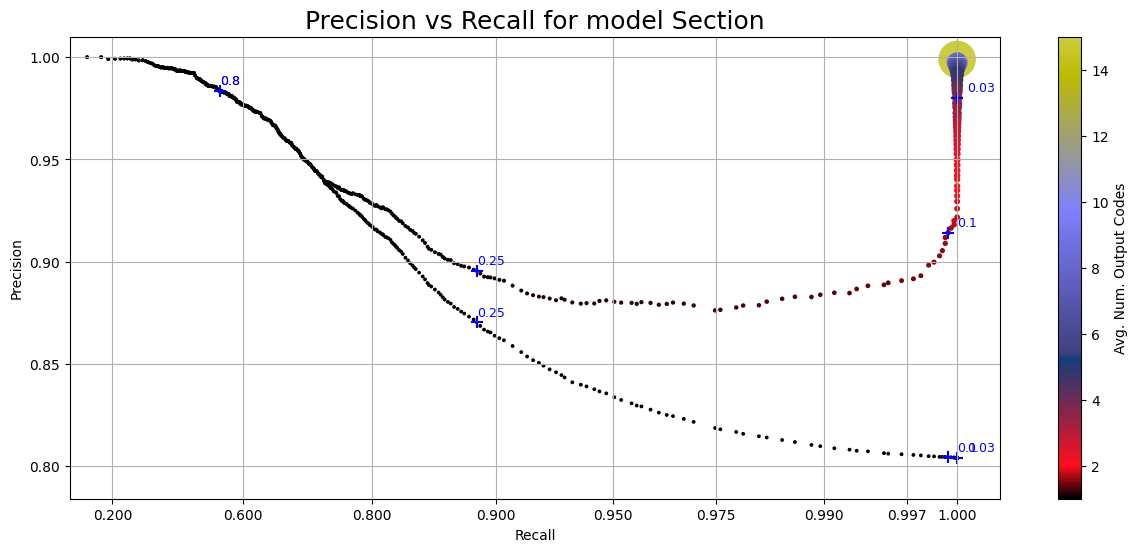

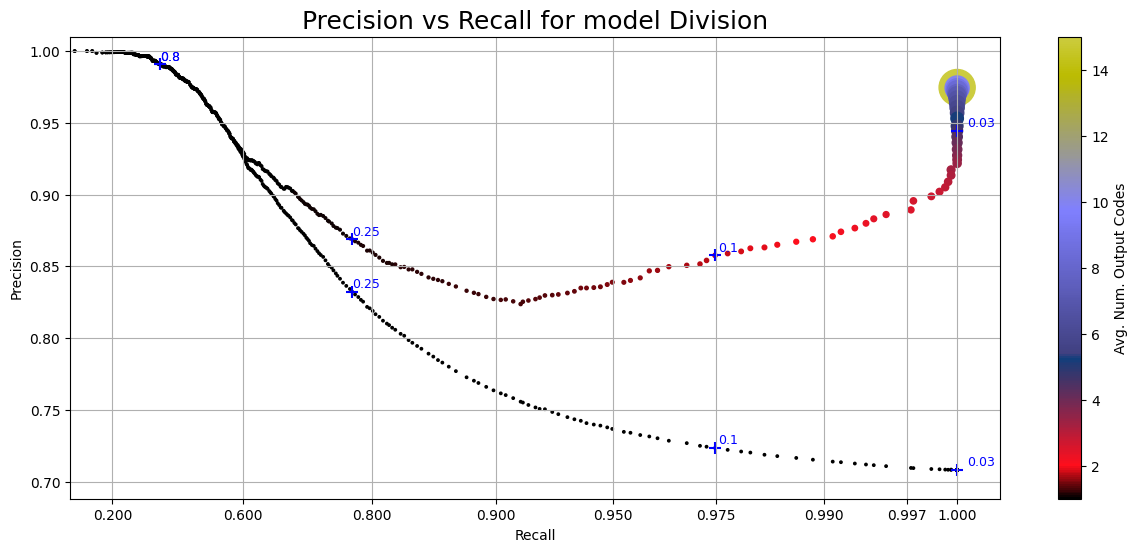

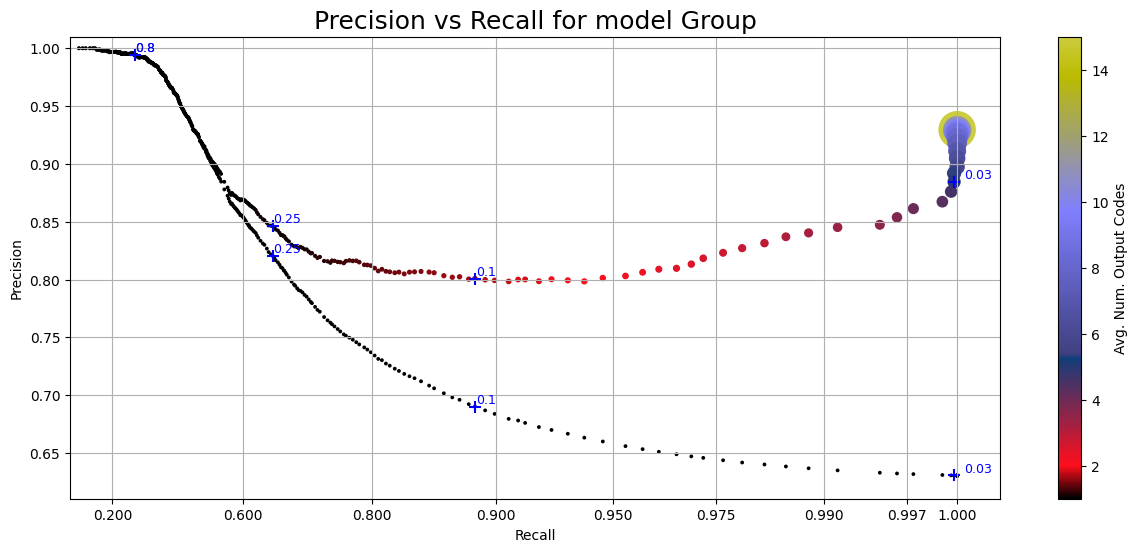

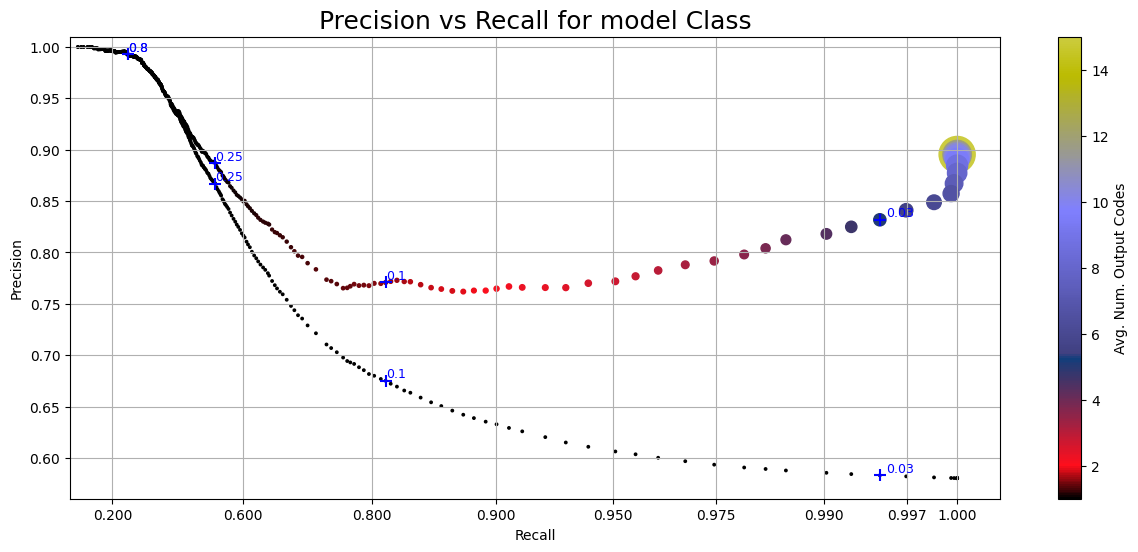

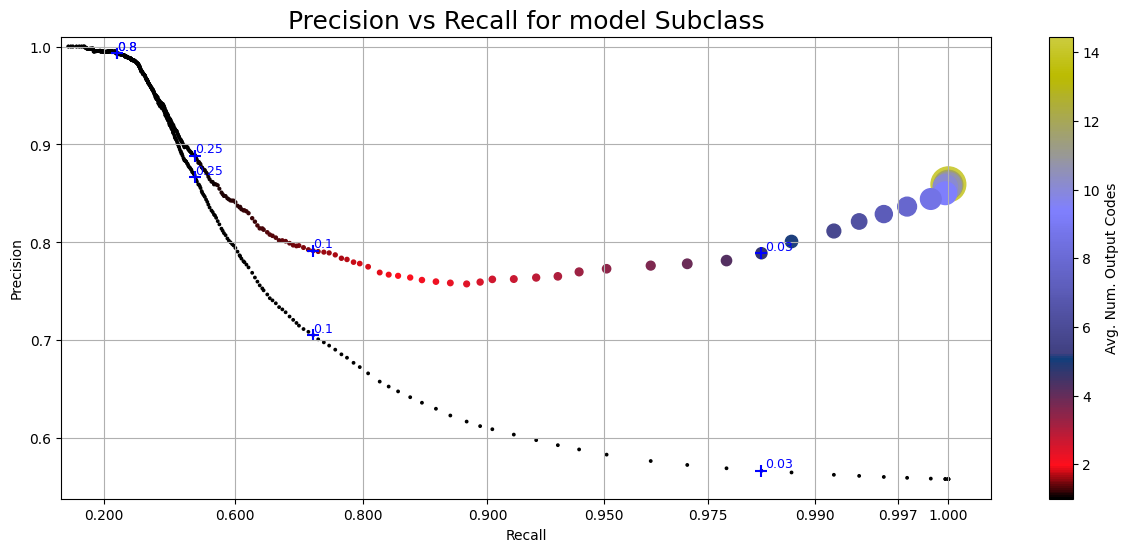

{'Section': {'accuracy': 0.8040562120728202,
  'f1_score': {'micro': 0.8040562120728202,
   'macro': 0.7317102737711878,
   'weighted': 0.7971678399374031}},
 'Division': {'accuracy': 0.7080804854679016,
  'f1_score': {'micro': 0.7080804854679016,
   'macro': 0.6601359714309609,
   'weighted': 0.6984902770594784}},
 'Group': {'accuracy': 0.6304694985627595,
  'f1_score': {'micro': 0.6304694985627595,
   'macro': 0.5515670262798558,
   'weighted': 0.6174423413292373}},
 'Class': {'accuracy': 0.5803257745129352,
  'f1_score': {'micro': 0.5803257745129352,
   'macro': 0.4820367238994799,
   'weighted': 0.5647718922099709}},
 'Subclass': {'accuracy': 0.5582880868732034,
  'f1_score': {'micro': 0.5582880868732034,
   'macro': 0.44428761509153464,
   'weighted': 0.5373548107634541}}}

In [67]:
wz_codifier.evaluate()